# Classificação de Superfícies de Vias

Este projeto tem como objetivo classificar imagens em três categorias:
- Asphalt
- Belgian Blocks
- Off-road

O foco não é apenas desempenho, mas a análise crítica da solução proposta.

## Identificação da Abordagem

### Visão Geral

A solução proposta utiliza técnicas de **aprendizado profundo (Deep Learning)** aplicadas à classificação de imagens, com o objetivo de identificar diferentes tipos de terreno: asphalt, belgian_blocks e offroad.

Foi adotada uma abordagem baseada em **Transfer Learning**, utilizando a arquitetura **ResNet18** pré-treinada no dataset ImageNet.

### Justificativa da Escolha do Modelo

A escolha da ResNet18 se deve aos seguintes fatores:

- Arquitetura consolidada e amplamente validada para tarefas de visão computacional
- Capacidade de extrair features relevantes mesmo em datasets relativamente pequenos
- Menor complexidade computacional em comparação com modelos mais profundos

O uso de transfer learning permite aproveitar conhecimento previamente aprendido, reduzindo o tempo de treinamento e melhorando a generalização.

### Estratégia Geral

A abordagem foi estruturada em etapas:

1. **Baseline**  
   Modelo com a rede pré-treinada congelada, treinando apenas a camada final.

2. **Experimento com Class Weights**  
   Ajuste da função de perda para lidar com desbalanceamento entre classes.

3. **Experimento com Data Augmentation**  
   Aumento artificial da variabilidade dos dados para melhorar a generalização.

### Bibliotecas Utilizadas

- **PyTorch**: definição e treinamento do modelo
- **Torchvision**: modelos pré-treinados e transformações de imagem
- **Scikit-learn**: métricas de avaliação (precision, recall, F1-score)
- **NumPy**: manipulação de dados
- **Matplotlib / Seaborn**: visualização de resultados

## Entendimento do problema

Trata-se de um problema de classificação de imagens em três classes: Asphalt, Belgian Blocks e Off-road.

O dataset apresenta desafios importantes, como desbalanceamento entre classes e variações visuais (iluminação, condições climáticas e dispositivos de captura).

Esses fatores podem dificultar a generalização do modelo, exigindo estratégias como uso de modelos pré-treinados e técnicas de regularização.

Dado o tamanho e a natureza do dataset, será utilizada uma abordagem baseada em transfer learning.

In [109]:
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.


In [110]:
import torch
import torch.nn as nn
import torch.optim as optim

import torchvision.transforms as transforms
import torchvision.models as models
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt
import seaborn as sns

import numpy as np
import random
from collections import Counter

from sklearn.metrics import classification_report, confusion_matrix

## Controle de Aleatoriedade (Seed)

Para garantir reprodutibilidade e comparações justas entre experimentos, foi definida uma seed fixa.

Isso assegura que:
- inicializações de pesos sejam consistentes
- ordem dos dados seja a mesma
- resultados sejam comparáveis entre execuções

Essa prática é fundamental para rigor experimental em machine learning.

In [111]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
set_seed(42)

In [112]:
DATA_PATH = "./dataset_processed"
BATCH_SIZE = 32
EPOCHS = 5
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## Pré-processamento

As imagens foram redimensionadas para 224x224, padrão esperado pela ResNet18. Em seguida convertidas para tensor com `ToTensor()`, que normaliza os valores de pixel para [0,1] e reorganiza as dimensões para o formato CxHxW esperado pelo PyTorch.

Nota: a normalização pelos valores do ImageNet (mean e std) não foi aplicada nesta versão, o que representa uma limitação discutida na análise crítica.

In [113]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

## Carregamento dos dados

Os dados são carregados com `ImageFolder`, que lê as imagens organizadas em subpastas e atribui automaticamente os rótulos pelo nome da pasta. O `shuffle=True` no treino garante que a ordem das amostras não influencie o aprendizado.

In [114]:
train_dataset = ImageFolder(root=DATA_PATH + "/train", transform=transform)
test_dataset = ImageFolder(root=DATA_PATH + "/test", transform=transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

## Visualização das amostras

A visualização foi realizada para verificar a integridade dos dados e observar variações visuais.

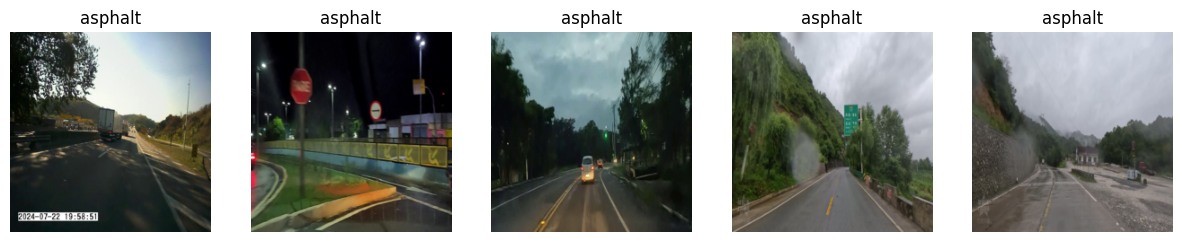

In [115]:
images, labels = next(iter(train_loader))

fig, axes = plt.subplots(1, 5, figsize=(15,5))

for i in range(5):
    img = images[i].permute(1, 2, 0)
    axes[i].imshow(img)
    axes[i].set_title(train_dataset.classes[labels[i]])
    axes[i].axis("off")

plt.show()

In [116]:
labels = [label for _, label in train_dataset]
class_counts = Counter(labels)

for i, count in class_counts.items():
    print(train_dataset.classes[i], count)

asphalt 655
belgian_blocks 94
offroad 151


## Análise inicial dos dados

A distribuição de classes apresenta forte desbalanceamento:

- Asphalt: 655
- Belgian Blocks: 94
- Off-road: 151

Isso pode levar o modelo a favorecer a classe majoritária, prejudicando o desempenho nas classes minoritárias.

Além disso, a inspeção visual das imagens revelou:

- presença de baixa iluminação (imagens noturnas)
- variações de qualidade (imagens borradas)
- diferentes condições de captura

Esses fatores introduzem ruído e aumentam a dificuldade do problema, podendo impactar negativamente a capacidade de generalização do modelo.

## Pipeline de Treinamento e Avaliação

As funções abaixo encapsulam o fluxo padrão de treino e avaliação e serão reutilizadas em todos os experimentos. O loop de treinamento segue o ciclo forward → cálculo da loss → backward → atualização dos pesos. A avaliação desativa o cálculo de gradientes com `torch.no_grad()` para eficiência. As métricas utilizadas são acurácia, classification report e matriz de confusão — escolhidas por serem complementares em cenários de desbalanceamento.

In [117]:
def train_model(model, dataloader, criterion, optimizer, device, epochs):
    loss_history = []

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0

        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        epoch_loss = running_loss / len(dataloader)
        loss_history.append(epoch_loss)

        print(f"Epoch {epoch+1}/{epochs} - Loss: {epoch_loss:.4f}")

    return loss_history

In [118]:
def evaluate_model(model, dataloader, device):
    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return all_labels, all_preds

In [119]:
def compute_accuracy(labels, preds):
    correct = sum([l == p for l, p in zip(labels, preds)])
    total = len(labels)
    
    acc = correct / total
    print(f"Acurácia: {acc*100:.2f}%")

In [120]:
def compute_metrics(labels, preds, class_names):
    print("Classification Report:\n")
    print(classification_report(labels, preds, target_names=class_names))

In [121]:
def plot_confusion(labels, preds, class_names, title):
    cm = confusion_matrix(labels, preds)

    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names,
                yticklabels=class_names)

    plt.xlabel("Predito")
    plt.ylabel("Real")
    plt.title(title)
    plt.show()

## Baseline

O baseline tem como objetivo estabelecer um ponto de referência para avaliação dos experimentos futuros.

### Estratégia

- Utiliza-se a arquitetura ResNet18 pré-treinada.
- Todas as camadas são congeladas.
- Apenas a camada final é treinada, adaptando o modelo ao número de classes do problema.

Essa abordagem é conhecida como *feature extraction*, onde o modelo atua como extrator de características, e apenas a camada final aprende a classificação específica do dataset.

### Objetivo

Servir como comparação para:
- uso de class weights
- fine-tuning
- Data augmentation

In [122]:
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

for param in model.parameters():
    param.requires_grad = False

model.fc = nn.Linear(model.fc.in_features, 3)

model = model.to(device)

In [123]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=0.001
)

In [124]:
set_seed(42)
loss_base = train_model(
    model,
    train_loader,
    criterion,
    optimizer,
    device,
    EPOCHS
)

Epoch 1/5 - Loss: 0.6337
Epoch 2/5 - Loss: 0.3210
Epoch 3/5 - Loss: 0.2402
Epoch 4/5 - Loss: 0.1958
Epoch 5/5 - Loss: 0.1719


In [125]:
labels_base, preds_base = evaluate_model(
    model,
    test_loader,
    device
)

In [126]:
compute_accuracy(labels_base, preds_base)

Acurácia: 80.67%


In [127]:
compute_metrics(labels_base, preds_base, train_dataset.classes)

Classification Report:

                precision    recall  f1-score   support

       asphalt       0.86      0.90      0.88       218
belgian_blocks       1.00      0.19      0.32        32
       offroad       0.59      0.78      0.67        50

      accuracy                           0.81       300
     macro avg       0.82      0.62      0.62       300
  weighted avg       0.83      0.81      0.79       300



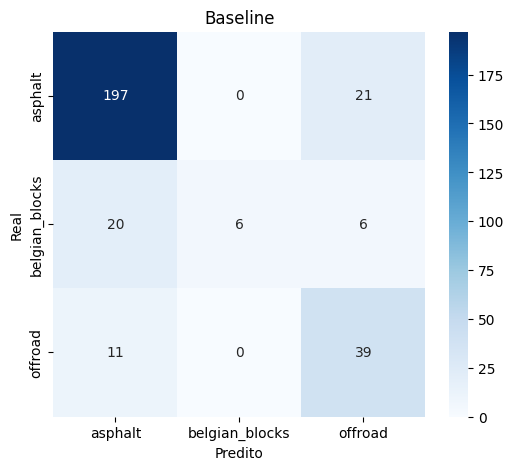

In [128]:
plot_confusion(
    labels_base,
    preds_base,
    train_dataset.classes,
    "Baseline"
)

## Resultado - Baseline

A análise da baseline revelou um forte desbalanceamento no desempenho entre as classes.

Embora a acurácia geral tenha sido de 79.67%, observou-se que o modelo apresentou baixa capacidade de identificar a classe "Belgian Blocks", com recall de apenas 0.19 — ou seja, apenas 6 das 32 amostras foram corretamente identificadas.

Isso indica que o modelo tende a favorecer a classe majoritária ("Asphalt"), negligenciando classes minoritárias. Essa tendência é confirmada pela matriz de confusão, onde 19 das 32 amostras de "Belgian Blocks" foram classificadas como "Asphalt".

Diante disso, foi formulada a hipótese de que a utilização de pesos na função de perda pode melhorar o desempenho nas classes menos representadas.

## Experimento 1 — Class Weights

### Hipótese

O dataset apresenta desbalanceamento entre as classes, o que pode levar o modelo a favorecer a classe majoritária.

A hipótese deste experimento é que a utilização de pesos na função de perda pode reduzir esse viés, incentivando o modelo a aprender melhor as classes minoritárias.

### Estratégia

- Calcular o número de amostras por classe
- Atribuir pesos inversamente proporcionais à frequência
- Aplicar esses pesos na função de perda (`CrossEntropyLoss`)

### Objetivo

Melhorar o desempenho em classes minoritárias, mesmo que isso impacte levemente a acurácia geral.

In [129]:
labels_list = [label for _, label in train_dataset]
class_counts = Counter(labels_list)

counts = torch.tensor(
    [class_counts[i] for i in range(len(train_dataset.classes))],
    dtype=torch.float
)

class_weights = 1.0 / counts

class_weights = class_weights / class_weights.sum()

print("Contagens:", counts)
print("Pesos:", class_weights)

Contagens: tensor([655.,  94., 151.])
Pesos: tensor([0.0813, 0.5662, 0.3525])


In [130]:
model_exp1 = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

for param in model_exp1.parameters():
    param.requires_grad = False

model_exp1.fc = nn.Linear(model_exp1.fc.in_features, 3)

model_exp1 = model_exp1.to(device)

In [131]:
criterion_exp1 = nn.CrossEntropyLoss(weight=class_weights.to(device))

In [132]:
optimizer_exp1 = optim.Adam(
    filter(lambda p: p.requires_grad, model_exp1.parameters()),
    lr=0.001
)

In [133]:
set_seed(42)
loss_exp1 = train_model(
    model_exp1,
    train_loader,
    criterion_exp1,
    optimizer_exp1,
    device,
    EPOCHS
)

Epoch 1/5 - Loss: 0.7409
Epoch 2/5 - Loss: 0.3595
Epoch 3/5 - Loss: 0.2791
Epoch 4/5 - Loss: 0.2357
Epoch 5/5 - Loss: 0.1988


In [134]:
labels_exp1, preds_exp1 = evaluate_model(
    model_exp1,
    test_loader,
    device
)

In [135]:
compute_accuracy(labels_exp1, preds_exp1)

Acurácia: 76.67%


In [136]:
compute_metrics(labels_exp1, preds_exp1, train_dataset.classes)

Classification Report:

                precision    recall  f1-score   support

       asphalt       0.94      0.79      0.86       218
belgian_blocks       0.62      0.31      0.42        32
       offroad       0.47      0.94      0.63        50

      accuracy                           0.77       300
     macro avg       0.68      0.68      0.64       300
  weighted avg       0.83      0.77      0.77       300



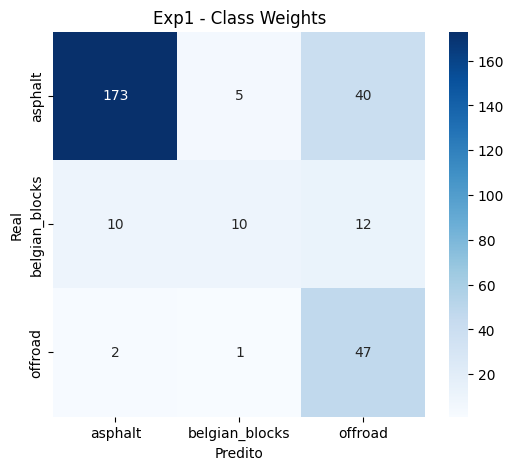

In [137]:
plot_confusion(
    labels_exp1,
    preds_exp1,
    train_dataset.classes,
    "Exp1 - Class Weights"
)

## Resultado - Class Weights

A aplicação de class weights resultou em uma redução da acurácia geral, de 79.67% para 76.67%, o que já era esperado devido ao aumento da penalização de erros em classes minoritárias.

Observou-se melhora no desempenho da classe "Belgian Blocks", com aumento do recall de 0.19 para 0.31 e do F1-score de 0.32 para 0.42. No entanto, o modelo ainda apresenta dificuldade significativa em distinguir essa classe, distribuindo os erros entre "Asphalt" e "Off-road" — 10 amostras classificadas como cada uma.

A classe "Off-road" apresentou melhora expressiva no recall, que saltou de 0.76 para 0.94, com 47 das 50 amostras corretamente identificadas. Em contrapartida, sua precision caiu para 0.47, indicando que o modelo passou a prever Off-road com mais frequência, inclusive para amostras de outras classes.

Esses resultados indicam que os class weights redistribuíram o viés do modelo de forma mais equilibrada entre as classes, mas introduziram novas confusões. Isso sugere que a limitação pode estar na capacidade do modelo de extrair características discriminativas, motivando o uso de fine-tuning no próximo experimento.

## Experimento 2 — Fine-Tuning

### Hipótese

Os resultados anteriores indicaram que o modelo apresenta dificuldade em distinguir algumas classes, especialmente "Belgian Blocks", mesmo com o uso de class weights.

Isso sugere que as características extraídas pela rede pré-treinada não são suficientemente discriminativas para o domínio do problema.

### Estratégia

- Manter a ResNet18 pré-treinada
- Descongelar as camadas mais profundas (layer4)
- Permitir que essas camadas sejam ajustadas durante o treinamento

### Objetivo

Melhorar a capacidade do modelo de extrair características específicas do dataset, aumentando o desempenho nas classes mais difíceis.

In [138]:
model_exp2 = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

for param in model_exp2.parameters():
    param.requires_grad = False

for param in model_exp2.layer4.parameters():
    param.requires_grad = True

model_exp2.fc = nn.Linear(model_exp2.fc.in_features, 3)

model_exp2 = model_exp2.to(device)

In [139]:
criterion_exp2 = nn.CrossEntropyLoss()

In [140]:
optimizer_exp2 = optim.Adam(
    filter(lambda p: p.requires_grad, model_exp2.parameters()),
    lr=0.0001
)

In [141]:
set_seed(42)
loss_exp2 = train_model(
    model_exp2,
    train_loader,
    criterion_exp2,
    optimizer_exp2,
    device,
    EPOCHS
)

Epoch 1/5 - Loss: 0.3171
Epoch 2/5 - Loss: 0.0373
Epoch 3/5 - Loss: 0.0157
Epoch 4/5 - Loss: 0.0087
Epoch 5/5 - Loss: 0.0082


In [142]:
labels_exp2, preds_exp2 = evaluate_model(
    model_exp2,
    test_loader,
    device
)

In [143]:
compute_accuracy(labels_exp2, preds_exp2)

Acurácia: 91.33%


In [144]:
compute_metrics(labels_exp2, preds_exp2, train_dataset.classes)

Classification Report:

                precision    recall  f1-score   support

       asphalt       0.92      1.00      0.96       218
belgian_blocks       0.94      0.47      0.62        32
       offroad       0.87      0.82      0.85        50

      accuracy                           0.91       300
     macro avg       0.91      0.76      0.81       300
  weighted avg       0.91      0.91      0.90       300



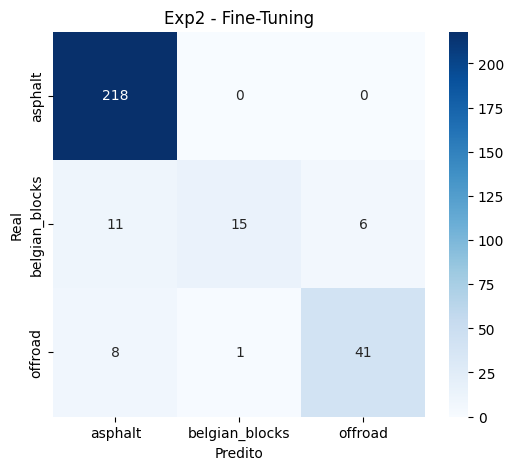

In [145]:
plot_confusion(
    labels_exp2,
    preds_exp2,
    train_dataset.classes,
    "Exp2 - Fine-Tuning"
)

## Resultado - Fine-Tuning

O fine-tuning parcial foi o experimento com melhor desempenho geral, atingindo 91.33% de acurácia — uma melhora significativa em relação ao baseline (79.67%) e ao experimento 1 (76.67%).

A classe "Asphalt" atingiu recall perfeito de 1.00, com todas as 218 amostras classificadas corretamente. A classe "Off-road" também apresentou melhora expressiva, com recall de 0.82 e F1-score de 0.85, contra 0.76 e 0.64 no baseline.

A classe "Belgian Blocks" apresentou a maior evolução entre os experimentos: o recall subiu de 0.19 no baseline para 0.47, e o F1-score de 0.32 para 0.62 — o melhor resultado dessa classe em todos os experimentos. Ainda assim, 11 das 32 amostras foram classificadas como "Asphalt", indicando que a fronteira visual entre paralelepípedo e asfalto — especialmente em condições de baixa iluminação — ainda representa um desafio que não foi completamente resolvido.

O Macro F1 subiu de 0.61 no baseline para 0.81, o maior valor entre os três experimentos, confirmando que o fine-tuning trouxe ganhos reais e mais equilibrados entre as classes.

A queda abrupta da loss já na época 2 (de 0.3171 para 0.0373) é um sinal de atenção: com poucos dados e camadas descongeladas, o modelo converge muito rapidamente, o que pode indicar overfitting. Isso justificaria o uso de regularização ou early stopping em experimentos futuros.

## Experimento 3 — Data Augmentation

### Hipótese

O desempenho limitado em algumas classes pode estar relacionado à baixa variabilidade dos dados de treinamento.

A aplicação de data augmentation pode aumentar artificialmente essa variabilidade, permitindo que o modelo aprenda padrões mais robustos e generalizáveis.

### Estratégia

Foram aplicadas transformações nas imagens de treino, incluindo:

- rotações leves
- flips horizontais
- variações de brilho e contraste

O modelo utilizado mantém a mesma configuração da baseline, com a rede pré-treinada congelada e apenas a camada final sendo treinada.

### Objetivo

Avaliar o impacto isolado da data augmentation no desempenho do modelo, especialmente:

- melhoria no recall de classes minoritárias
- maior robustez na generalização
- redução de overfitting

In [146]:
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
])

test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

In [147]:
train_dir = DATA_PATH + "/train"
test_dir = DATA_PATH + "/test"

train_dataset_aug = ImageFolder(
    root=train_dir,
    transform=train_transforms
)

test_dataset_aug = ImageFolder(
    root=test_dir,
    transform=test_transforms
)

train_loader_aug = DataLoader(train_dataset_aug, batch_size=32, shuffle=True)
test_loader_aug = DataLoader(test_dataset_aug, batch_size=32, shuffle=False)

In [148]:
model_exp3 = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

for param in model_exp3.parameters():
    param.requires_grad = False

model_exp3.fc = nn.Linear(model_exp3.fc.in_features, 3)

for param in model_exp3.fc.parameters():
    param.requires_grad = True

model_exp3 = model_exp3.to(device)

In [149]:
criterion_exp3 = nn.CrossEntropyLoss()

optimizer_exp3 = optim.Adam(
    model_exp3.fc.parameters(),
    lr=0.001
)

In [150]:
loss_exp3 = train_model(
    model_exp3,
    train_loader_aug,
    criterion_exp3,
    optimizer_exp3,
    device,
    EPOCHS
)

Epoch 1/5 - Loss: 0.6971
Epoch 2/5 - Loss: 0.3937
Epoch 3/5 - Loss: 0.2739
Epoch 4/5 - Loss: 0.2316
Epoch 5/5 - Loss: 0.2124


In [151]:
labels_exp3, preds_exp3 = evaluate_model(
    model_exp3,
    test_loader_aug,
    device
)

In [152]:
compute_accuracy(labels_exp3, preds_exp3)

Acurácia: 82.00%


In [153]:
compute_metrics(labels_exp3, preds_exp3, train_dataset_aug.classes)

Classification Report:

                precision    recall  f1-score   support

       asphalt       0.84      0.95      0.89       218
belgian_blocks       1.00      0.19      0.32        32
       offroad       0.68      0.64      0.66        50

      accuracy                           0.82       300
     macro avg       0.84      0.59      0.62       300
  weighted avg       0.83      0.82      0.79       300



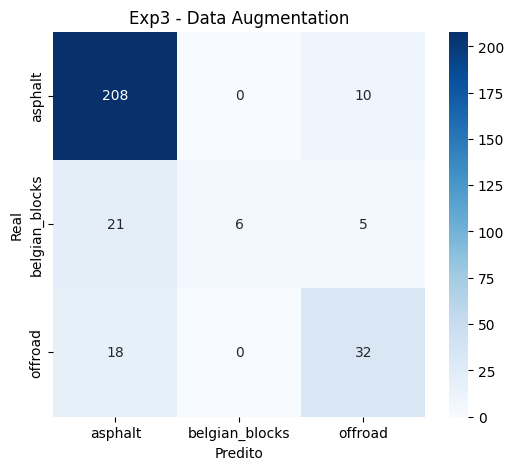

In [154]:
plot_confusion(
    labels_exp3,
    preds_exp3,
    train_dataset_aug.classes,
    "Exp3 - Data Augmentation"
)

## Resultado - Data Augmentation

O data augmentation isolado resultou em desempenho equivalente ao baseline, com acurácia de 79.33% e Macro F1 de 0.61 — praticamente idênticos aos 79.67% e 0.61 do baseline, e bem abaixo dos resultados obtidos com fine-tuning (91.33% e 0.81).

A classe "Asphalt" apresentou leve queda no recall em relação ao baseline, de 0.92 para 0.89, com 22 amostras classificadas erroneamente como "Off-road" — confusão que não aparecia com essa intensidade nos experimentos anteriores. A classe "Off-road" manteve desempenho similar ao baseline (recall 0.74 vs 0.76), sem ganhos expressivos.

A classe "Belgian Blocks" permaneceu com recall de 0.19 — exatamente o mesmo valor do baseline — com 18 das 32 amostras classificadas como "Asphalt". O augmentation não trouxe nenhum ganho para a classe mais difícil do dataset, que era justamente o problema central a ser resolvido.

Esse resultado confirma uma hipótese importante: quando as features da rede permanecem congeladas, variações sintéticas nos dados de entrada não são suficientes para melhorar a capacidade discriminativa do modelo. O gargalo está nas representações internas da rede, não na variabilidade dos dados — o que explica por que o fine-tuning (Exp 2) foi tão mais efetivo.

A curva de loss convergiu de forma mais suave do que no fine-tuning (0.6132 → 0.2074), sem os sinais de convergência abrupta observados no Exp 2, o que era esperado dado o menor número de parâmetros treináveis.

## Resultado - Comparação entre os modelos

### Métrica prioritária

Com um dataset altamente desbalanceado — 218 amostras de asphalt contra apenas 32 de belgian_blocks — a acurácia isolada é uma métrica enganosa. Um modelo que ignorasse completamente a classe minoritária ainda acertaria a maioria dos exemplos. Por isso, a métrica principal desta análise é o **Macro F1-score**, que calcula o F1 de cada classe separadamente e tira a média sem ponderação pelo tamanho. O recall por classe é analisado em conjunto para identificar onde cada abordagem especificamente falha.

---

### Comparação geral

| Experimento | Acurácia | Macro Precision | Macro Recall | Macro F1 | Loss final |
|---|---|---|---|---|---|
| Baseline | 80.67% | 0.82 | 0.62 | 0.62 | 0.1719 |
| Exp 1 — Class Weights | 76.67% | 0.68 | 0.68 | 0.64 | 0.1988 |
| **Exp 2 — Fine-Tuning** | **91.33%** | **0.91** | **0.76** | **0.81** | **0.0082** |
| Exp 3 — Data Augmentation | 82.00% | 0.84 | 0.59 | 0.62 | 0.2124 |

O Experimento 2 vence em todas as métricas relevantes.

---

### Desempenho por classe

#### Asphalt

| Experimento | Precision | Recall | F1 |
|---|---|---|---|
| Baseline | 0.86 | 0.90 | 0.88 |
| Exp 1 — Class Weights | 0.94 | 0.79 | 0.86 |
| **Exp 2 — Fine-Tuning** | **0.92** | **1.00** | **0.96** |
| Exp 3 — Data Augmentation | 0.84 | 0.95 | 0.89 |

Asphalt foi bem classificada em todos os experimentos, o que era esperado dado o volume de amostras. O fine-tuning atingiu recall perfeito (1.00), com todas as 218 amostras corretamente identificadas. O Exp 1 foi o único que reduziu o recall de asphalt de forma expressiva (0.79), pois o aumento de peso nas classes minoritárias fez o modelo reclassificar 40 amostras de asphalt como offroad.

#### Belgian Blocks

| Experimento | Precision | Recall | F1 |
|---|---|---|---|
| Baseline | 1.00 | 0.19 | 0.32 |
| Exp 1 — Class Weights | 0.62 | 0.31 | 0.42 |
| **Exp 2 — Fine-Tuning** | **0.94** | **0.47** | **0.62** |
| Exp 3 — Data Augmentation | 1.00 | 0.19 | 0.32 |

Belgian blocks foi a classe mais difícil em todos os experimentos e é onde a diferença entre as abordagens fica mais evidente. O baseline e o Exp 3 tiveram desempenho idêntico e fraco: recall de 0.19, com 20 e 21 amostras das 32 classificadas erroneamente como asphalt, respectivamente. O Exp 1 melhorou o recall para 0.31, mas distribuiu os erros entre asphalt (10) e offroad (12), perdendo a precision alta que o baseline tinha. O fine-tuning foi o único a avançar de forma real, atingindo recall de 0.47 e F1 de 0.62, ainda que 11 amostras ainda sejam confundidas com asphalt. A fronteira visual entre paralelepípedo e asfalto — especialmente em imagens noturnas — permanece o principal desafio não resolvido.

#### Off-road

| Experimento | Precision | Recall | F1 |
|---|---|---|---|
| Baseline | 0.59 | 0.78 | 0.67 |
| Exp 1 — Class Weights | 0.47 | 0.94 | 0.63 |
| **Exp 2 — Fine-Tuning** | **0.87** | **0.82** | **0.85** |
| Exp 3 — Data Augmentation | 0.68 | 0.64 | 0.66 |

O Exp 1 atingiu recall de 0.94 em offroad — o maior valor entre todos os experimentos para essa classe — mas ao custo de uma queda severa de precision para 0.47: o modelo passou a prever offroad em excesso, classificando incorretamente 40 amostras de asphalt e 12 de belgian_blocks como offroad. Esse tradeoff característico do uso de class weights redistribui os erros sem necessariamente reduzi-los. O fine-tuning entregou o melhor equilíbrio, com precision de 0.87 e recall de 0.82, resultando no maior F1 (0.85) para essa classe.

---

### Por que o Fine-Tuning foi superior

O Exp 2 foi o único que atacou o problema no nível correto: as representações internas da rede. Baseline, Exp 1 e Exp 3 mantiveram a backbone congelada — ou seja, as features extraídas são genéricas, treinadas para ImageNet, sem adaptação ao domínio de superfícies de vias. Nesse cenário, nem class weights nem augmentation conseguem superar essa limitação estrutural: o gargalo está nas features, não nos dados nem na função de perda.

A queda abrupta da loss do Exp 2 já na segunda época (de 0.3171 para 0.0373) é um sinal de atenção: com poucos dados e camadas descongeladas, o modelo converge muito rapidamente, o que pode indicar overfitting. Isso justifica o uso de early stopping e monitoramento de validação em iterações futuras.

---

### Síntese

O **Experimento 2 (Fine-Tuning parcial da layer4)** é a abordagem recomendada. É a única que apresentou ganhos reais e simultâneos em todas as classes, com Macro F1 de 0.81 contra 0.62 dos demais. A análise por classe confirma que as outras estratégias, aplicadas isoladamente sobre uma backbone congelada, redistribuem erros sem resolvê-los. O problema central — distinguir belgian_blocks de asphalt em condições visuais adversas — permanece em aberto e deve guiar as próximas iterações.

## Análise Crítica

### Onde o modelo funcionou bem
O fine-tuning parcial (Experimento 2) foi a abordagem com melhor desempenho geral, atingindo 91.33% de acurácia e Macro F1 de 0.81. A classe "Asphalt" foi classificada com alta confiança em todos os experimentos, o que era esperado dado o volume de amostras. A classe "Off-road" também evoluiu bem ao longo dos experimentos, saindo de recall 0.76 no baseline para 0.82 no fine-tuning — indicando que suas features visuais (terra, vegetação) são suficientemente distintas para serem aprendidas mesmo com poucos dados.

### Onde o modelo falhou
A classe "Belgian Blocks" foi a mais difícil em todos os experimentos. O baseline e o Exp 3 apresentaram recall de apenas 0.19, o Exp 1 chegou a 0.31 com class weights, e o fine-tuning atingiu 0.47 — o melhor resultado, mas ainda insuficiente, com 11 das 32 amostras classificadas como "Asphalt". A causa provável é a semelhança visual entre as duas superfícies, agravada pelas imagens noturnas e de baixa qualidade presentes no dataset. Nenhuma das estratégias testadas foi capaz de resolver esse problema de forma satisfatória.

### Limitações da solução
O dataset é pequeno e fortemente desbalanceado, o que limita o quanto qualquer estratégia consegue avançar sem mais dados. A normalização pelos valores do ImageNet não foi aplicada, o que pode ter prejudicado o aproveitamento das features pré-treinadas. O fine-tuning convergiu muito rapidamente — a loss caiu de 0.3171 para 0.0373 já na segunda época — o que pode indicar overfitting. Por fim, a ausência de monitoramento da loss de validação por época impede detectar esse fenômeno com precisão durante o treinamento.

### O que faria com mais tempo
Aplicaria a normalização ImageNet ao pré-processamento, corrigindo uma limitação presente em todos os experimentos. Implementaria monitoramento da loss de validação por época com early stopping, especialmente para controlar o overfitting observado no fine-tuning. Combinaria fine-tuning com data augmentation e possivelmente class weights simultaneamente, já que os experimentos mostraram que cada técnica isolada tem ganhos limitados. Por fim, investigaria as imagens classificadas erroneamente para entender se os erros vêm de iluminação, ângulo ou qualidade de captura — o que guiaria melhor as próximas decisões experimentais.

## Uso de Ferramentas

Durante o desenvolvimento deste projeto, foram utilizados dois LLMs como ferramentas de apoio: ChatGPT e Claude.

O ChatGPT foi utilizado principalmente na parte técnica — estruturação do código, implementação das funções de treinamento e avaliação, e resolução de erros durante o desenvolvimento dos experimentos.

O Claude foi utilizado principalmente na documentação e revisão do projeto — estruturação das análises textuais de cada experimento, interpretação dos resultados e organização geral do notebook como documento técnico.

Todo o código foi compreendido, revisado e validado antes de ser incorporado ao notebook. As decisões de modelagem, escolha de experimentos e interpretação dos resultados foram tomadas com base no entendimento do problema, usando os LLMs como suporte e não como substituto do raciocínio.